# **FOOTBALL PLAYERS STATS ANALYTICS (2024–25)**

In [1]:
!pip install pyspark
!pip install -U -q PyDrive
!apt install openjdk-8-jdk-headless &> /dev/null

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 40.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Footaball players stats analytics") \
    .config("spark.ui.port", "4050") \
    .getOrCreate()

In [4]:
from pyspark import SparkContext
sc = SparkContext.getOrCreate()


In [5]:
from google.colab import files
uploaded = files.upload()

Saving players_data_light-2024_2025.csv to players_data_light-2024_2025.csv


In [6]:
df = spark.read.csv("players_data_light-2024_2025.csv", header=True, inferSchema=True)

In [7]:
df.printSchema()
print("Rows:", df.count())
print("Cols:", len(df.columns))
print("Partitions:", df.rdd.getNumPartitions())

df.show(5, truncate=100)

root
 |-- Rk: integer (nullable = true)
 |-- Player: string (nullable = true)
 |-- Nation: string (nullable = true)
 |-- Pos: string (nullable = true)
 |-- Squad: string (nullable = true)
 |-- Comp: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Born: integer (nullable = true)
 |-- MP: integer (nullable = true)
 |-- Starts: integer (nullable = true)
 |-- Min: integer (nullable = true)
 |-- 90s: double (nullable = true)
 |-- Gls: integer (nullable = true)
 |-- Ast: integer (nullable = true)
 |-- G+A: integer (nullable = true)
 |-- G-PK: integer (nullable = true)
 |-- PK: integer (nullable = true)
 |-- PKatt: integer (nullable = true)
 |-- CrdY: integer (nullable = true)
 |-- CrdR: integer (nullable = true)
 |-- xG: double (nullable = true)
 |-- npxG: double (nullable = true)
 |-- xAG: double (nullable = true)
 |-- npxG+xAG: double (nullable = true)
 |-- G+A-PK: double (nullable = true)
 |-- xG+xAG: double (nullable = true)
 |-- PrgC: integer (nullable = true)
 |-- Prg

# **Top Goal Scorer from Each League**

In [14]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, desc, col

windowSpec = Window.partitionBy("Comp").orderBy(desc("Gls"))

top4_df = df.withColumn("rank", rank().over(windowSpec)) \
            .filter(col("rank") <= 1) \
            .select("Comp", "Player", "Gls", "rank")

top4_df.show(20, truncate=False)

+------------------+---------------+---+----+
|Comp              |Player         |Gls|rank|
+------------------+---------------+---+----+
|de Bundesliga     |Harry Kane     |26 |1   |
|eng Premier League|Mohamed Salah  |29 |1   |
|es La Liga        |Kylian Mbappé  |31 |1   |
|fr Ligue 1        |Ousmane Dembélé|21 |1   |
|fr Ligue 1        |Mason Greenwood|21 |1   |
|it Serie A        |Mateo Retegui  |25 |1   |
+------------------+---------------+---+----+



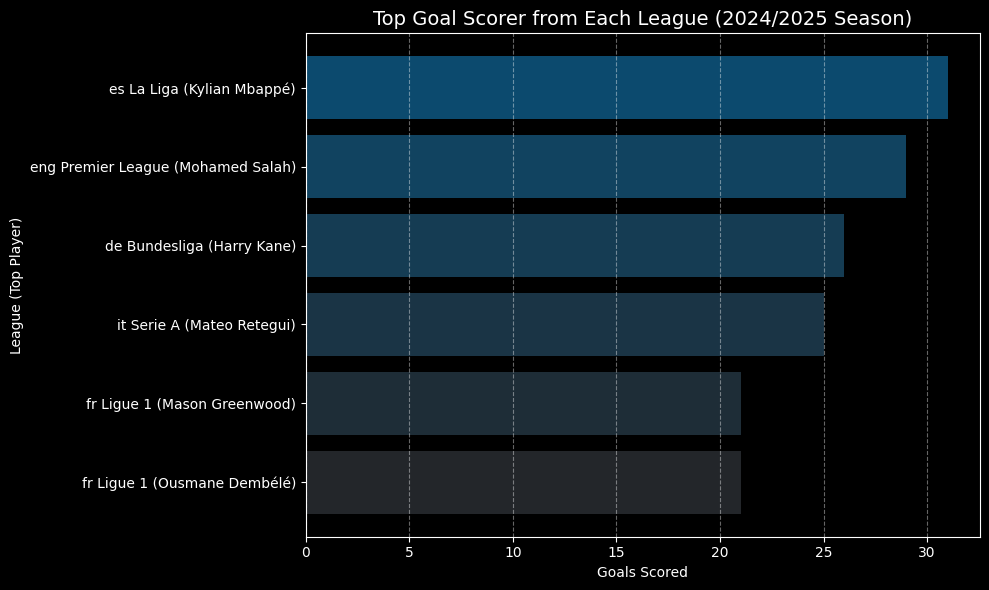

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top4_pd = top4_df.toPandas()
plt.style.use("dark_background")

top4_pd = top4_pd.sort_values(by="Gls", ascending=True)

colors = sns.color_palette("dark:#0C4A6E", n_colors=len(top4_pd))

plt.figure(figsize=(10, 6))
plt.barh(
    top4_pd["Comp"] + " (" + top4_pd["Player"] + ")",
    top4_pd["Gls"],
    color=colors
)

plt.xlabel("Goals Scored", color='white')
plt.ylabel("League (Top Player)", color='white')
plt.title("Top Goal Scorer from Each League (2024/2025 Season)", fontsize=14, color='white')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/top_goal_scorer.png", dpi=300)
plt.show()


# **Top 10 Goal Scorers**

In [8]:
numeric_cols = [f.name for f in df.schema.fields if str(f.dataType)[:6] == "Double"]
for c in numeric_cols:
    df = df.fillna({c: 0})

In [10]:
from pyspark.sql import functions as F

df = df.withColumn("Goal_Contribution", F.col("Gls") + F.col("Ast"))
df = df.withColumn("GC_per90", (F.col("Goal_Contribution") / (F.col("90s") + 0.001)))
df = df.withColumn("Goal_xG_Ratio", F.col("Gls") / (F.col("xG") + 0.001))

In [11]:
top_goals = df.groupBy("Player", "Squad").agg(F.sum("Gls").alias("Goals")) \
              .orderBy(F.desc("Goals")).limit(10)
top_goals.show()

+------------------+---------------+-----+
|            Player|          Squad|Goals|
+------------------+---------------+-----+
|     Kylian Mbappé|    Real Madrid|   31|
|     Mohamed Salah|      Liverpool|   29|
|Robert Lewandowski|      Barcelona|   27|
|        Harry Kane|  Bayern Munich|   26|
|     Mateo Retegui|       Atalanta|   25|
|    Alexander Isak|  Newcastle Utd|   23|
|    Erling Haaland|Manchester City|   22|
|   Mason Greenwood|      Marseille|   21|
|      Ante Budimir|        Osasuna|   21|
|   Ousmane Dembélé|      Paris S-G|   21|
+------------------+---------------+-----+



/tmp/ipython-input-3126751053.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Goals", y="Player", data=top_goals_pd, palette="cividis")


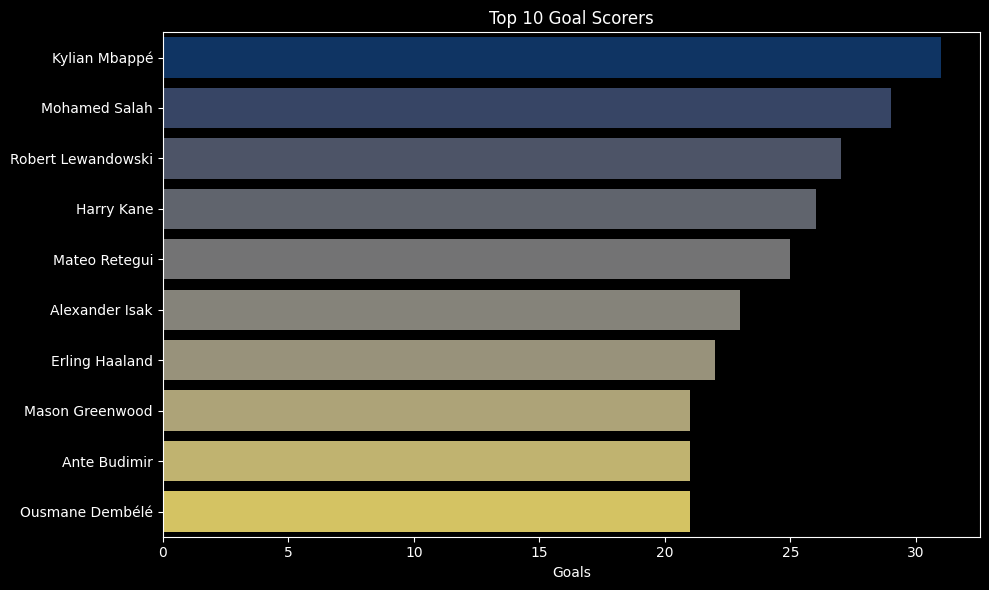

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

top_goals_pd = top_goals.toPandas()

plt.style.use("dark_background")
plt.figure(figsize=(10,6))
sns.barplot(x="Goals", y="Player", data=top_goals_pd, palette="cividis")
plt.title("Top 10 Goal Scorers")
plt.xlabel("Goals")
plt.ylabel("")
plt.tight_layout()
plt.savefig("/content/top_goals.png", dpi=150)
plt.show()

# **Top 10 Assist Providers**

In [28]:
top_assists = df.groupBy("Player", "Squad").agg(F.sum("Ast").alias("Assists")) \
                .orderBy(F.desc("Assists")).limit(10)
top_assists.show()

+--------------+---------------+-------+
|        Player|          Squad|Assists|
+--------------+---------------+-------+
| Mohamed Salah|      Liverpool|     18|
| Michael Olise|  Bayern Munich|     15|
|  Lamine Yamal|      Barcelona|     13|
|  Jacob Murphy|  Newcastle Utd|     12|
| Florian Wirtz|     Leverkusen|     12|
|  Rayan Cherki|           Lyon|     11|
|Vincenzo Grifo|       Freiburg|     11|
|Anthony Elanga|Nott'ham Forest|     11|
| Gaëtan Perrin|        Auxerre|     11|
|   Bukayo Saka|        Arsenal|     10|
+--------------+---------------+-------+



# **Top 10 by G+A**

In [29]:
top_gca = df.groupBy("Player", "Squad").agg(
    (F.sum("Gls") + F.sum("Ast")).alias("G+A")
).orderBy(F.desc("G+A")).limit(10)
top_gca.show()

+------------------+-------------+---+
|            Player|        Squad|G+A|
+------------------+-------------+---+
|     Mohamed Salah|    Liverpool| 47|
|        Harry Kane|Bayern Munich| 35|
|     Kylian Mbappé|  Real Madrid| 34|
|     Mateo Retegui|     Atalanta| 33|
|    Alexander Isak|Newcastle Utd| 29|
|Robert Lewandowski|    Barcelona| 29|
|          Raphinha|    Barcelona| 27|
|   Ousmane Dembélé|    Paris S-G| 27|
|     Michael Olise|Bayern Munich| 27|
|      Bryan Mbeumo|    Brentford| 27|
+------------------+-------------+---+



# **Top 10 Defenders**

In [30]:
top_defenders = df.filter(df.Pos.like("DF%")).groupBy("Player","Squad").agg(
    F.sum("Tkl").alias("Total_Tackles"),
    F.sum("Int").alias("Interceptions"),
    F.sum("Clr").alias("Clearances")
).orderBy(F.desc("Total_Tackles")).limit(10)
top_defenders.show()

+--------------------+---------------+-------------+-------------+----------+
|              Player|          Squad|Total_Tackles|Interceptions|Clearances|
+--------------------+---------------+-------------+-------------+----------+
|        Daniel Muñoz| Crystal Palace|          123|           44|       108|
|   Noussair Mazraoui| Manchester Utd|          115|           34|        95|
|      Omar El Hilali|       Espanyol|          111|           46|       145|
|        Jon Aramburu|  Real Sociedad|          102|           30|        98|
|     Nahuel Tenaglia|         Alavés|           96|           47|       123|
|    Antonee Robinson|         Fulham|           95|           62|       133|
|     Tyrick Mitchell| Crystal Palace|           91|           19|       108|
|       Neco Williams|Nott'ham Forest|           90|           31|       137|
|     Rayan Aït-Nouri|         Wolves|           89|           26|        75|
|Victor Bernth Kri...| Leicester City|           87|           4

/tmp/ipython-input-3812683724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Total_Tackles", y="Player", data=top_defenders_pd, palette= "viridis")


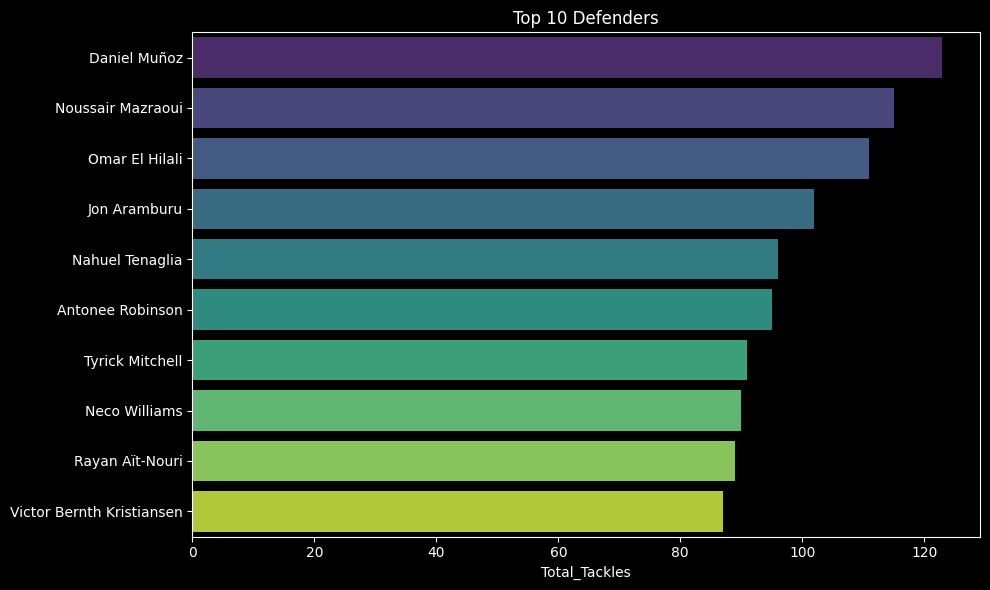

In [68]:
if 'top_defenders' in locals():
    top_defenders_pd = top_defenders.toPandas()

    plt.figure(figsize=(10,6))
    sns.barplot(x="Total_Tackles", y="Player", data=top_defenders_pd, palette= "viridis")
    plt.title("Top 10 Defenders")
    plt.xlabel("Total_Tackles")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("/content/top_defenders.png", dpi=150)
    plt.show()
else:
    print("The 'top_defenders' DataFrame is not available.")
plt.style.use("dark_background")

# **xG Outperformers by Team**

In [52]:
from pyspark.sql import functions as F

if "xG_Diff" not in df.columns and "Gls" in df.columns and "xG" in df.columns:
    df = df.withColumn("xG_Diff", (F.col("Gls") - F.col("xG")))
outperformers = (
    df.select("Player", "Squad", "Gls", "xG", "xG_Diff")
      .where(F.col("xG_Diff") > 1)
      .orderBy(F.desc("xG_Diff"))
      .limit(10)
)
print("Players outperforming their Expected Goals (xG):")
outperformers.show(truncate=False)

Players outperforming their Expected Goals (xG):
+-------------+---------------+---+----+-----------------+
|Player       |Squad          |Gls|xG  |xG_Diff          |
+-------------+---------------+---+----+-----------------+
|Patrik Schick|Leverkusen     |21 |12.7|8.3              |
|Bryan Mbeumo |Brentford      |20 |12.3|7.699999999999999|
|Chris Wood   |Nott'ham Forest|20 |13.4|6.6              |
|Matheus Cunha|Wolves         |15 |8.6 |6.4              |
|Ayoze Pérez  |Villarreal     |19 |12.7|6.300000000000001|
|Omar Marmoush|Eint Frankfurt |15 |8.8 |6.199999999999999|
|Mateo Retegui|Atalanta       |25 |18.9|6.100000000000001|
|Harry Kane   |Bayern Munich  |26 |20.3|5.699999999999999|
|Oihan Sancet |Athletic Club  |15 |9.7 |5.300000000000001|
|Kylian Mbappé|Real Madrid    |31 |25.9|5.100000000000001|
+-------------+---------------+---+----+-----------------+



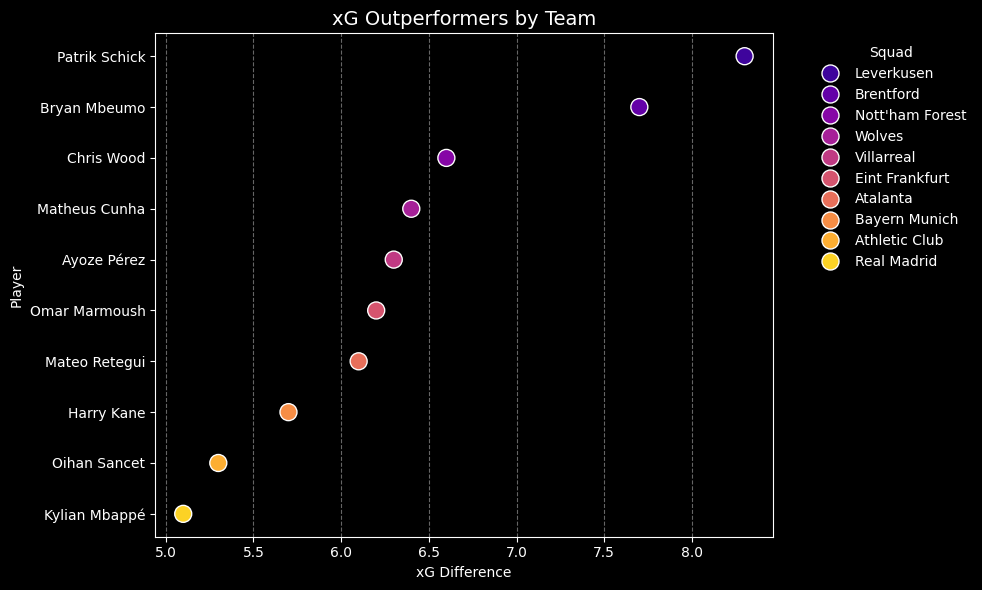

In [93]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=outperformers_pd,
    x="xG_Diff",
    y="Player",
    hue="Squad",
    palette="plasma",
    s=150,
)
plt.title("xG Outperformers by Team", fontsize=14, color='white')
plt.xlabel("xG Difference", color='white')
plt.ylabel("Player", color='white')
plt.legend(title="Squad", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("/content/xG_outperformers.png", dpi=300)
plt.show()


# **Top 10 Clubs by total goals**

In [37]:
top_clubs = df.groupBy("Squad").agg(
    F.sum("Gls").alias("Total_Goals"),
    F.sum("Ast").alias("Total_Assists"),
    F.countDistinct("Player").alias("Players_Used")
).orderBy(F.desc("Total_Goals")).limit(10)
top_clubs.show()

+---------------+-----------+-------------+------------+
|          Squad|Total_Goals|Total_Assists|Players_Used|
+---------------+-----------+-------------+------------+
|      Barcelona|         99|           72|          28|
|  Bayern Munich|         96|           66|          29|
|      Paris S-G|         89|           69|          28|
|      Liverpool|         85|           65|          24|
|    Real Madrid|         78|           55|          30|
|          Inter|         76|           57|          26|
|       Atalanta|         76|           54|          32|
|Manchester City|         71|           51|          30|
|      Marseille|         70|           49|          32|
|     Leverkusen|         70|           53|          23|
+---------------+-----------+-------------+------------+



/tmp/ipython-input-2622943121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Total_Goals", y="Squad", data=top_clubs_pd, palette="magma")


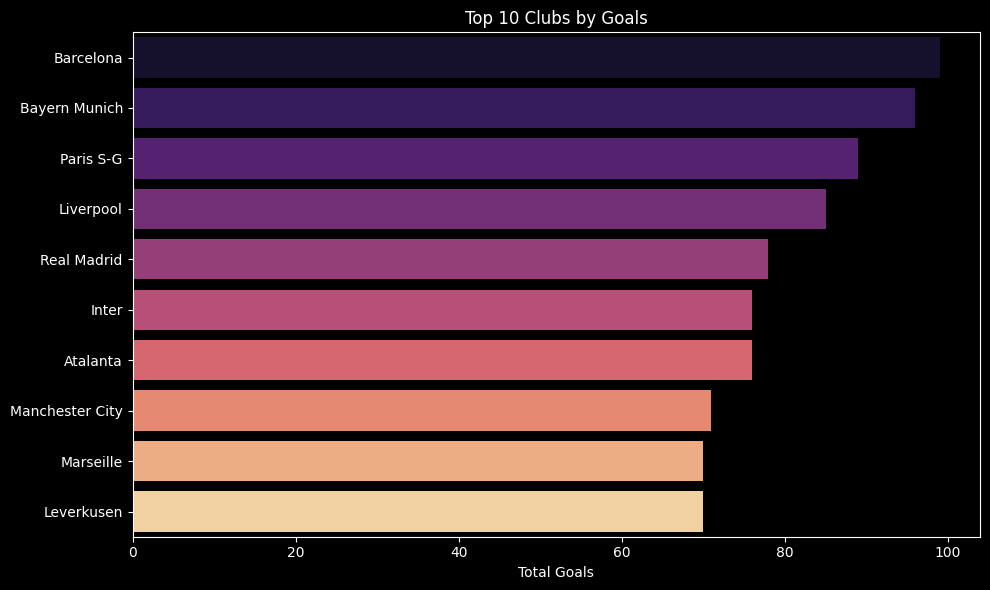

In [42]:
plt.figure(figsize=(10,6))
top_clubs_pd = top_clubs.toPandas()
sns.barplot(x="Total_Goals", y="Squad", data=top_clubs_pd, palette="magma")
plt.title("Top 10 Clubs by Goals")
plt.xlabel("Total Goals")
plt.ylabel("")
plt.tight_layout()
plt.savefig("/content/top_clubs.png", dpi=150)
plt.show()
plt.style.use("dark_background")

# **Top Football Club from Each League**

In [69]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

if "Comp" in df.columns and "Squad" in df.columns and "Gls" in df.columns:
    club_goals = (
        df.groupBy("Comp", "Squad")
          .agg(F.sum("Gls").alias("Total_Goals"))
    )

    windowSpec = Window.partitionBy("Comp").orderBy(F.desc("Total_Goals"))
    ranked_clubs = club_goals.withColumn("Rank", F.rank().over(windowSpec))

    top_clubs_each_league = ranked_clubs.filter(F.col("Rank") == 1).orderBy("Comp")

    print("Top Football Club from Each League (by Goals):")
    top_clubs_each_league.show(truncate=False)
else:
    print("Columns 'Comp', 'Squad', or 'Gls' not found in your dataset.")

Top Football Club from Each League (by Goals):
+------------------+-------------+-----------+----+
|Comp              |Squad        |Total_Goals|Rank|
+------------------+-------------+-----------+----+
|de Bundesliga     |Bayern Munich|96         |1   |
|eng Premier League|Liverpool    |85         |1   |
|es La Liga        |Barcelona    |99         |1   |
|fr Ligue 1        |Paris S-G    |89         |1   |
|it Serie A        |Inter        |76         |1   |
|it Serie A        |Atalanta     |76         |1   |
+------------------+-------------+-----------+----+



# **Goals vs Assists Comparison**

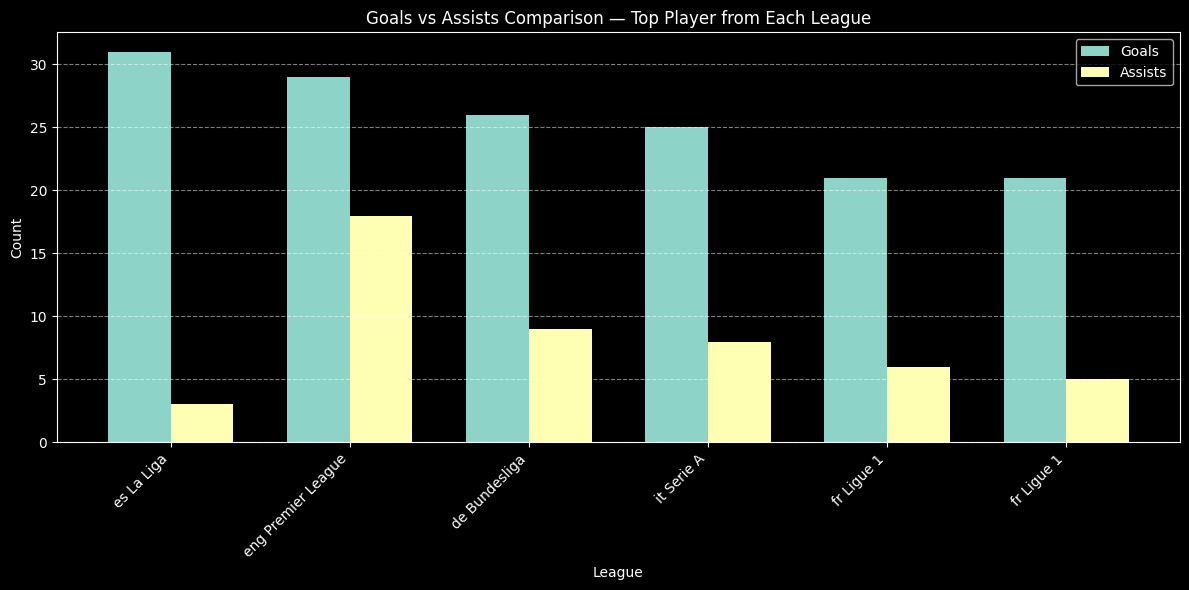

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

top4_pd = top4_df.toPandas()

if "Ast" not in top4_pd.columns and "Ast" in df.columns:
    top_ast = (
        df.groupBy("Comp", "Player")
          .agg(F.sum("Ast").alias("Ast"))
    )
    top4_pd = top4_pd.merge(top_ast.toPandas(), on=["Comp", "Player"], how="left")

top4_pd = top4_pd.sort_values(by="Gls", ascending=False).fillna(0)

x = np.arange(len(top4_pd["Comp"]))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, top4_pd["Gls"], width, label="Goals")
plt.bar(x + width/2, top4_pd["Ast"], width, label="Assists")
plt.xlabel("League")
plt.ylabel("Count")
plt.title("Goals vs Assists Comparison — Top Player from Each League")
plt.xticks(x, top4_pd["Comp"], rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("/content/goals_vs_assists.png", dpi=300)
plt.show()


# **Player Age Distribution**

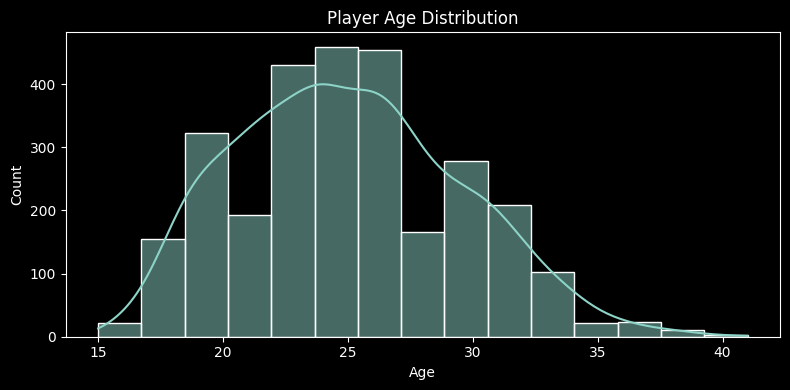

In [82]:
if "Age" in df.columns:
    ages = df.select("Age").toPandas()
    plt.figure(figsize=(8,4))
    sns.histplot(ages["Age"].dropna(), kde=True, bins=15)
    plt.title("Player Age Distribution")
    plt.tight_layout()
    plt.savefig("/content/age_dist.png", dpi=150)
    plt.show()
    plt.style.use("dark_background")

# **Percentage of Players per League**

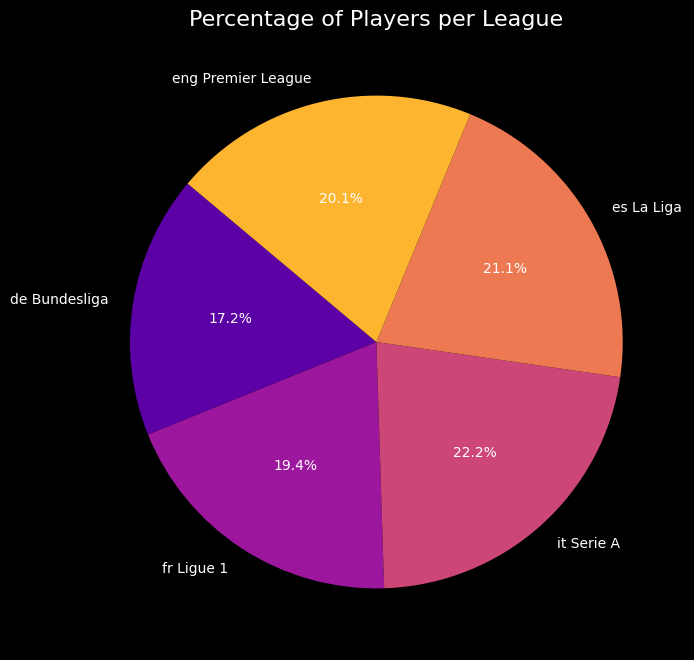

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import count

plt.style.use("dark_background")
if "Comp" in df.columns:
    league_counts = df.groupBy("Comp").agg(count("*").alias("player_count"))

    data = league_counts.collect()
    leagues = [row["Comp"] for row in data]
    player_counts = [row["player_count"] for row in data]

    colors = sns.color_palette("plasma", n_colors=len(leagues))

    plt.figure(figsize=(8, 8))
    plt.pie(
        player_counts,
        labels=leagues,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        textprops={'color': 'white'}
    )
    plt.title("Percentage of Players per League", fontsize=16, color='white')
    plt.savefig("/content/players_per_league.png", dpi=300)
    plt.show()
else:
    print("Column 'Comp' not found in the DataFrame.")
